In [1]:
import os
# Core scverse libraries
import scanpy as sc
import anndata as ad

# Data retrieval
#import pooch
import pandas as pd
#import os
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
## 去除批次效应 
## harmony
import scanpy.external as sce

sc.settings.verbosity = 0
sc.settings.set_figure_params(
    dpi=80,
    dpi_save=300, #保存本地图像的分辨率
    facecolor="white",
    frameon=True,  #是否添加框线
    figsize=(4, 4),
    format='pdf'
)


In [2]:
adata=sc.read_h5ad('../PCOS_analysis/04_double_cell_remove/adata_after_double.h5ad')

In [4]:
#adata.uns['log1p']['base'] =None
sc.tl.rank_genes_groups(
    adata, "Major_annotation_d", method="wilcoxon",key_added='dea_Major_annotation_1'
    ,pts=True
    ,use_raw=True  #默认就是用这个
)

/home/a3d9h01010/.local/lib/python3.10/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)


In [5]:
### 导出差异分析结果
groups=adata.uns['dea_Major_annotation_1']['names'].dtype.names

with pd.ExcelWriter('./07_双细胞后的大类差异分析_富集分析/07_Major_annotation_d_dea_results.xlsx') as writer:
    for group in groups:
        df=sc.get.rank_genes_groups_df(adata,group=group,key='dea_Major_annotation_1')
        df['group']=group
        ### 保存excel表格
        df.to_excel(writer,sheet_name=group)
    



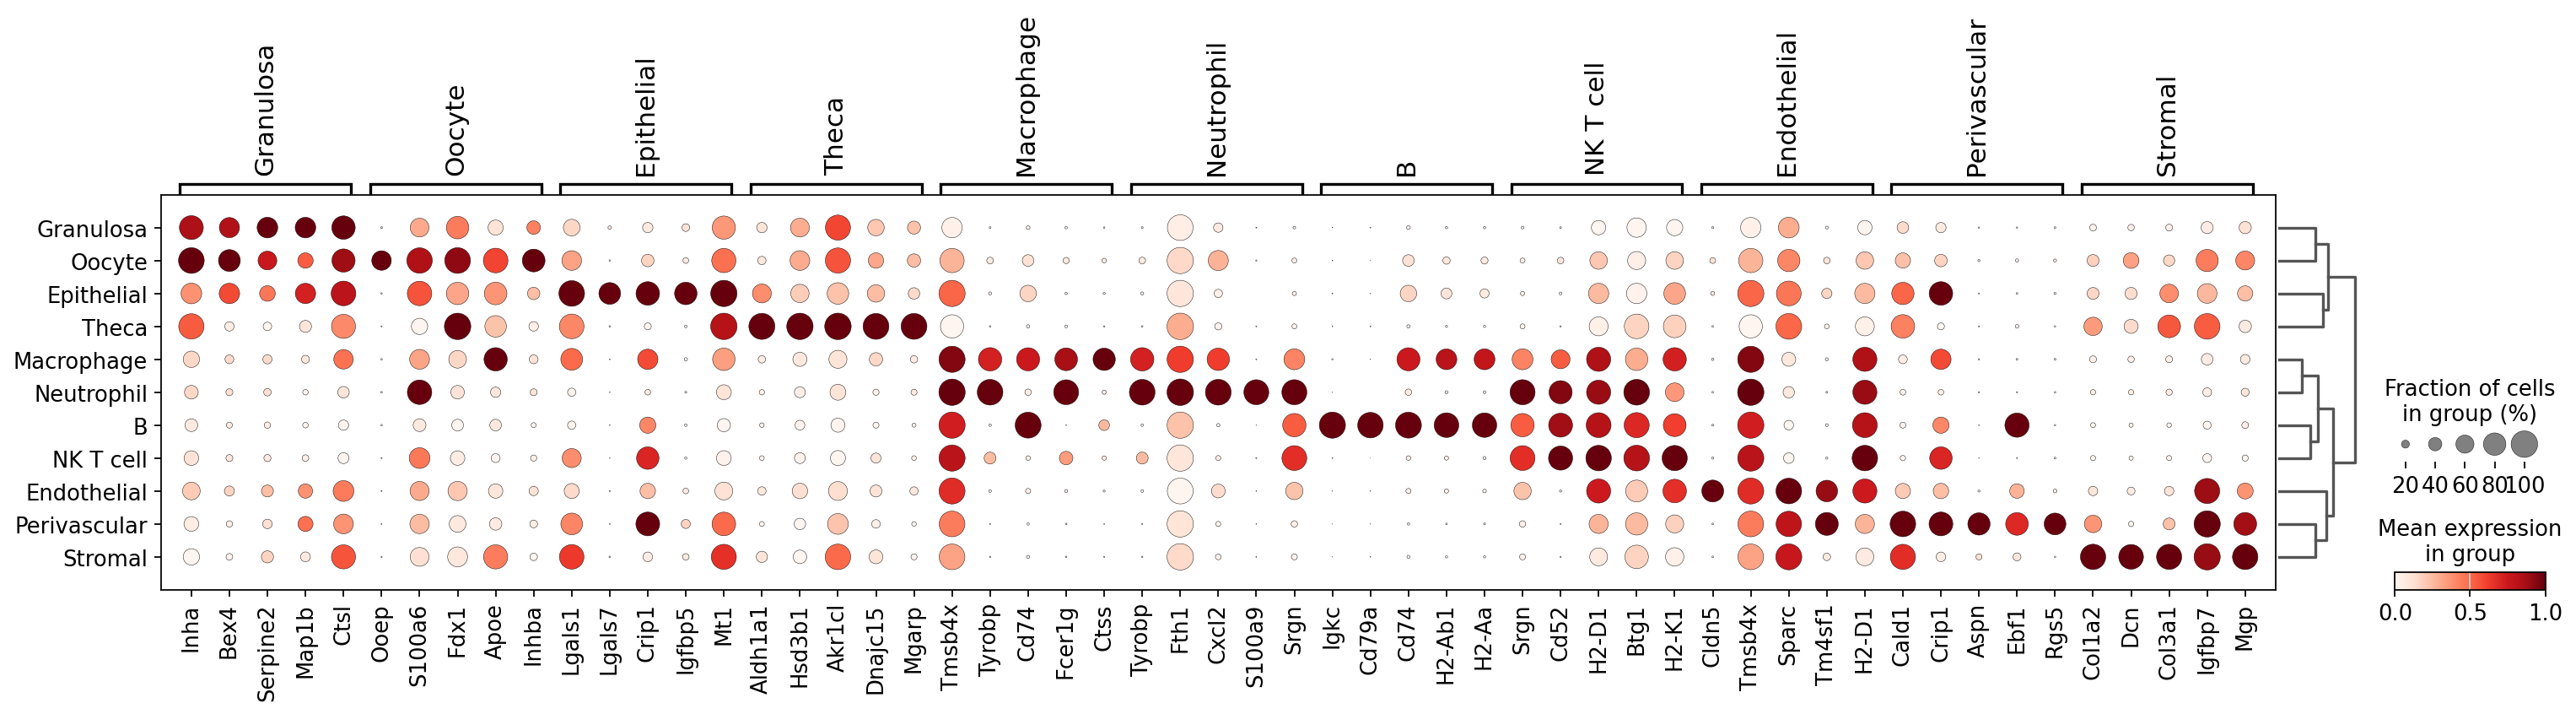

In [13]:
sc.pl.rank_genes_groups_dotplot(
    adata,
    groupby="Major_annotation_d",
    key='dea_Major_annotation_1',
    standard_scale="var",
    n_genes=5,
    show=False
)
plt.show()

In [14]:
adata.write('../PCOS_analysis/04_double_cell_remove/adata_after_double.h5ad')  ### 注释过的数据

In [ ]:
marker_genes_dict3 = {
    #'Germ':['Oct4','Par6'],
    'Epithelial':['Upk1b','Gpm6a','Krt19'],
    'Endothelial': ['Cldn5','Ebf1','Flt1'], #单核细胞
        'Oocyte':['Ooep','Ddx4','Bmp15'],
    'Granulosa': ['Fst','Camta1','Amh','Con2','Foxo1'], #颗粒细胞
    'Cumulus':['Hsd17b1','Inhbb','Ihh'], #卵丘细胞
    'Luteum':['Cyp11a1','Fdx1','Star'],
    'Mural':['Cited2','Aldh1a1'],
    'Primitive':['Wnt4','Wt1'],

    'Thecal': ['Cyp17a1'], #壁细胞
    'Stroma': ['Pdgfra','Dcn','Lum'], #单核细胞
    'Perivascular': ['Rgs5','Rergl','Mcam'], #单核细胞
    'Immune': ['Cd52'], #单核细胞
    'NK cells': ['Nkg7'], #NK 细胞
    'B cells': ['Cd19','Ms4a1', 'Cd79a', 'Cd79b'], #B 细胞
    'T cells': ['Cd3d',  'Cd3g','Cd8a'], #T 细胞
    #'Dendritic cells': ['Itgax'], #树突状细胞
    'Monocytes': ['Cd68','Cd14',], #单核细胞
    
    

}

In [15]:
dea_name='dea_Major_annotation_1'
groups=adata.uns[dea_name]['names'].dtype.names
groups

('B',
 'Endothelial',
 'Epithelial',
 'Granulosa',
 'Macrophage',
 'NK T cell',
 'Neutrophil',
 'Oocyte',
 'Perivascular',
 'Stromal',
 'Theca')

In [16]:
markers_dict_use={groups[0]:['Cd79a']
             ,groups[1]:['Cldn5']
             ,groups[2]:['Krt19']
             ,groups[3]:['Fst']
             ,groups[4]:['Lyz2']
             ,f"{groups[5]}_1":['Ccl5'] 
             ,f"{groups[5]}_2":['Nkg7']
             ,groups[6]:['S100a9']
             ,groups[7]:['Ooep']
             ,groups[8]:['Rgs5']
             ,groups[9]:['Dcn']
             ,groups[10]:['Cyp17a1']
            }

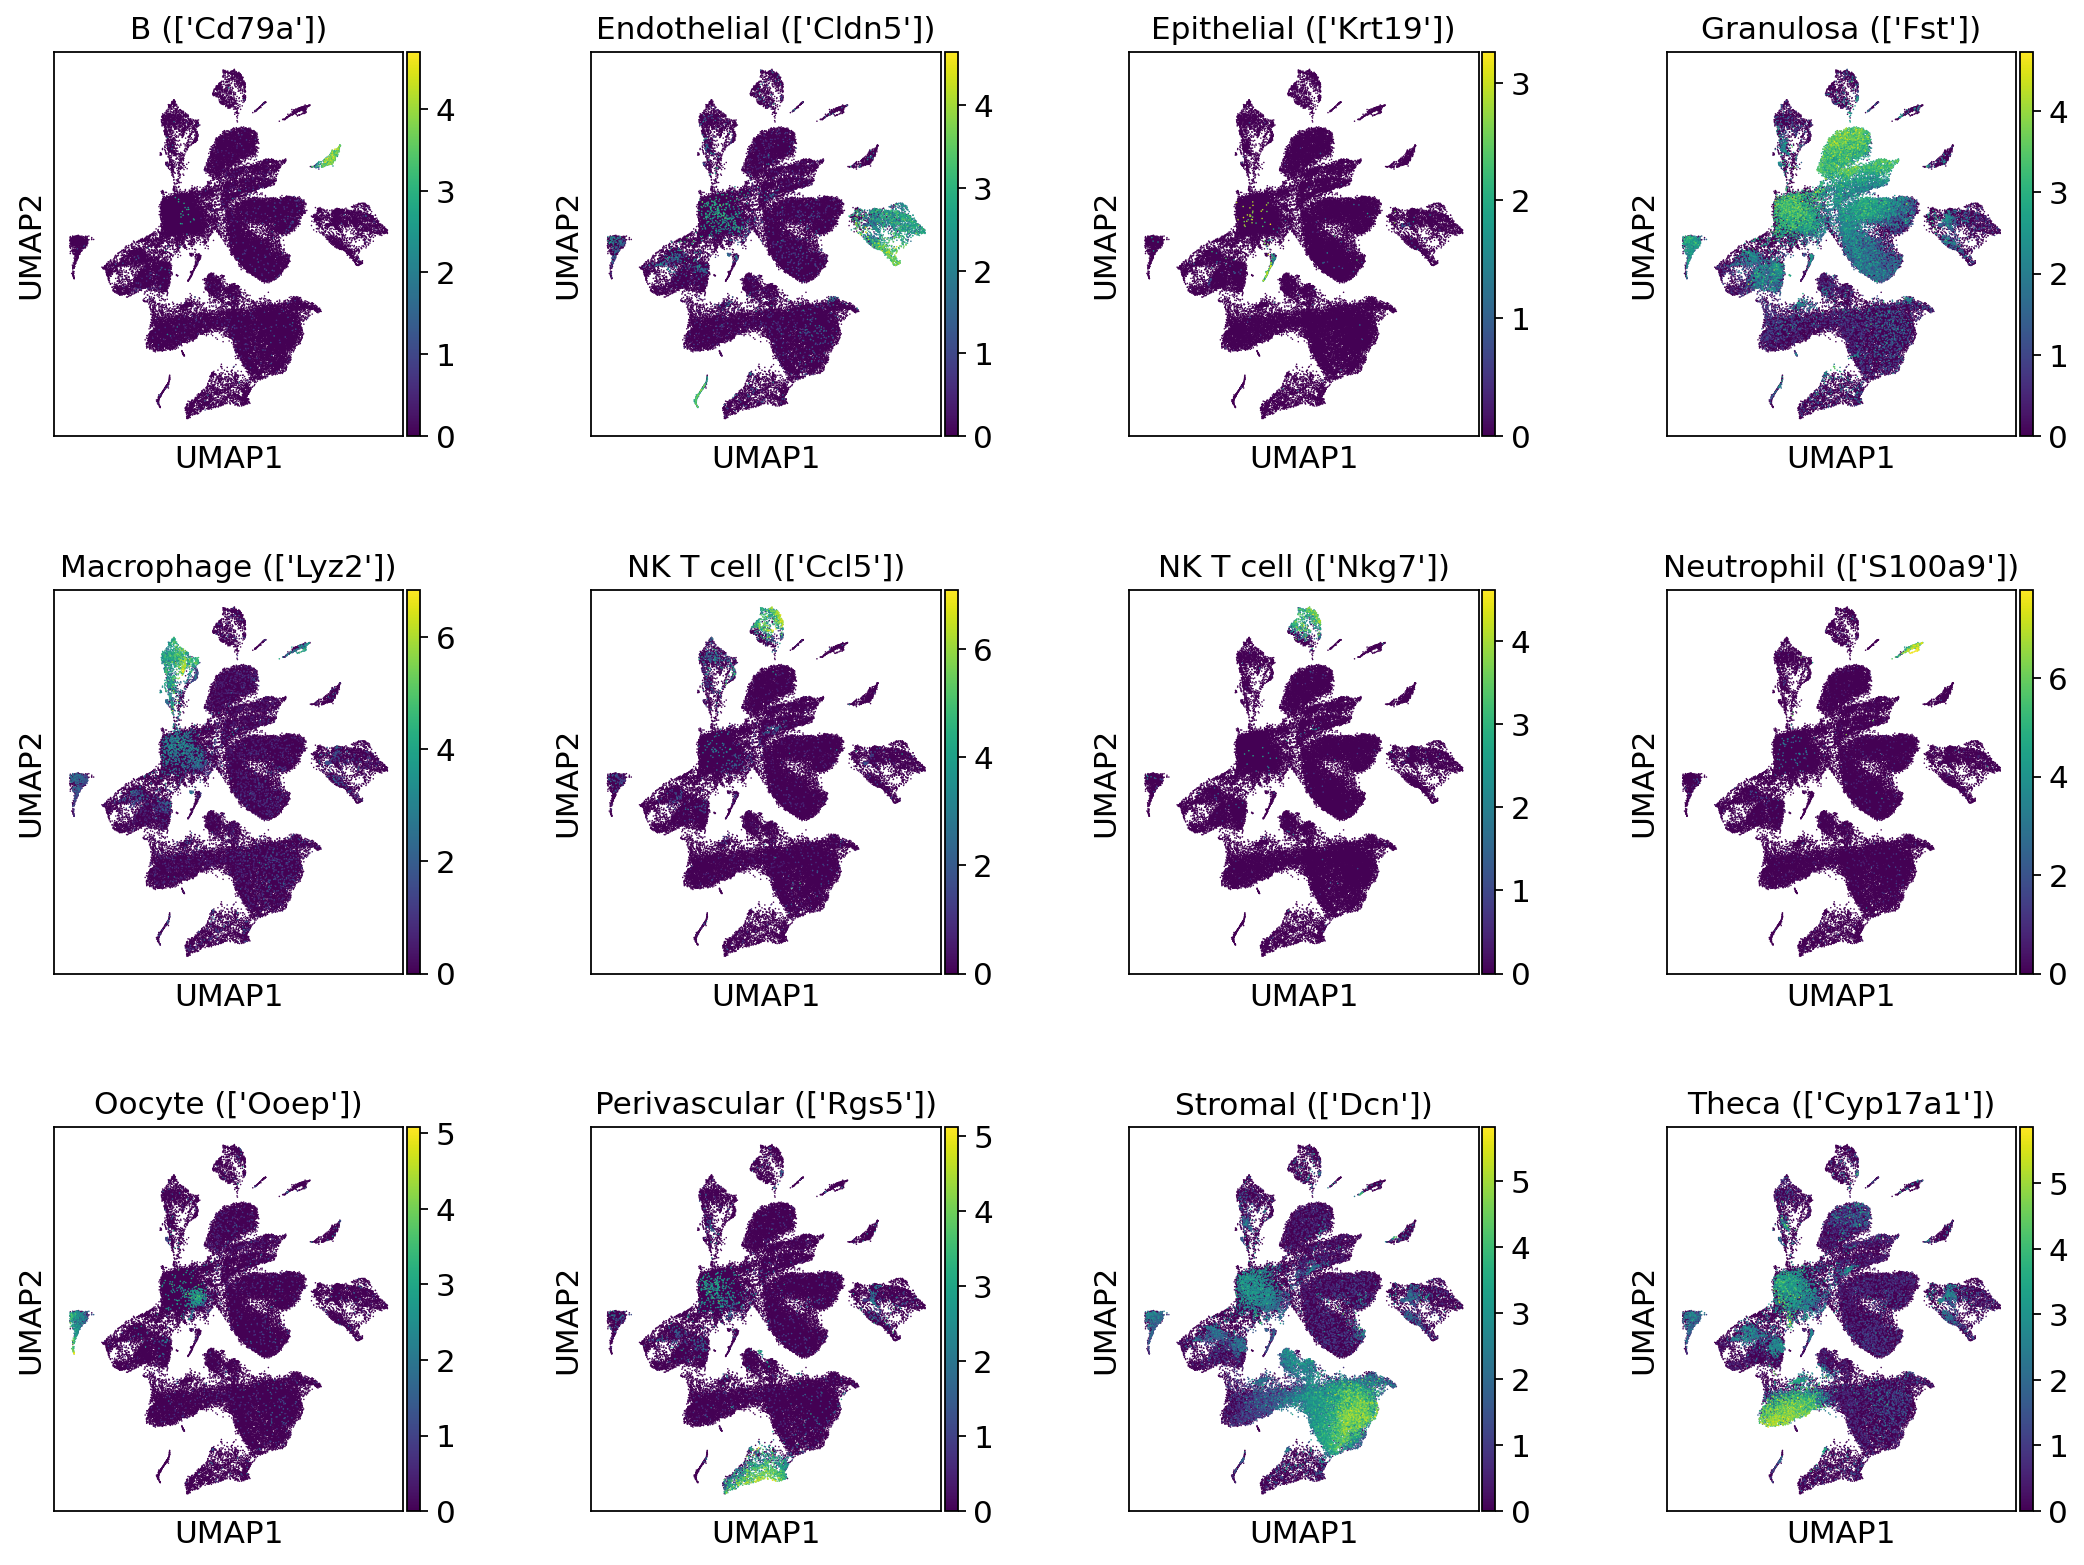

In [17]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages

# 创建3x4的子图布局
fig, axs = plt.subplots(3, 4, figsize=(16, 12), gridspec_kw={'wspace': 0.4, 'hspace': 0.4})

# 将axs从2D数组展平，便于迭代
axs_flat = axs.flatten()

# 假设markers_dict_use有12个key
for i, cell_type in enumerate(list(markers_dict_use.keys())):
    cell_type_a=cell_type.split('_')[0]
    title_use = f"{cell_type_a} ({markers_dict_use[cell_type]})"
    
    # 绘制UMAP图到指定的子图上
    sc.pl.umap(adata, 
               color=markers_dict_use[cell_type], 
               title=title_use,
               frameon=True,
               legend_fontsize=10,   
               ax=axs_flat[i], 
               show=False)

### 保存为pdf
plt.savefig("./figures/07_markers_umap_plots.pdf", format="pdf", bbox_inches='tight')
